<a href="https://colab.research.google.com/github/kyaw-koko/GCI-bag/blob/main/KyawZinOo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Powered Revenue Forecasting: Model Building

##Section 1: Project Overview & Objective

#Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from xgboost import XGBClassifier, plot_importance
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 120)


In [ ]:

# Run this cell only on Google Colab.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#%cd "/content/drive/MyDrive/WhereThisNotebookIsLocated"
%cd "/content/drive/MyDrive/"

/content/drive/MyDrive


In [ ]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /content/drive/MyDrive/telecom/Client.csv
OK  /content/drive/MyDrive/telecom/Record.csv


In [ ]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


In [ ]:
# Merge on Customer_ID. Both tables have one row per customer, so this is a 1:1 join.
df = record.merge(client, on='Customer_ID', how='inner')
print(f"Merged: {df.shape}")
df.head()

Merged: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


In [ ]:
# Target နှင့် မလိုအပ်သော Features များကို ဖယ်ရှားခြင်း
target = 'avgrev'
cols_to_drop = ['Customer_ID', 'churn']

# တကယ်ရှိနေတဲ့ column တွေကိုပဲ စစ်ပြီး ဖယ်ရှားမယ်
existing_cols_to_drop = [c for c in cols_to_drop if c in df.columns]

# Features နှင့် Target ခွဲထုတ်ခြင်း
X = df.drop(columns=existing_cols_to_drop + [target])
y = df[target]

print(f"Features: {X.shape[1]}")
print(f"Target: {target}")

Features: 97
Target: avgrev


In [ ]:
# Numerical columns များကို ရွေးထုတ်ခြင်း
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X_num = X[numeric_cols]

# Missing values ရှိရင် 0 နဲ့ အစားထိုးပေးမယ် (Error မတက်အောင်)
X_num = X_num.fillna(0)
y = y.fillna(y.mean())

print(f"Numerical Features အရေအတွက်: {len(numeric_cols)}")

Numerical Features အရေအတွက်: 76


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=42
)

# Scaling (Regression မော်ဒယ်အတွက် အရေးကြီးပါတယ်)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Cleaning & Splitting အောင်မြင်ပါသည်။")

Data Cleaning & Splitting အောင်မြင်ပါသည်။


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# RandomForest နေရာတွင် HistGradientBoostingRegressor ကို အစားထိုးသုံးခြင်း
# ဒါက ပိုမြန်ပြီး Data ကြီးတွေအတွက် ပိုသင့်တော်ပါတယ်
model = HistGradientBoostingRegressor(max_iter=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Prediction ပြုလုပ်ခြင်း
y_pred = model.predict(X_test_scaled)

# Metrics များ တွက်ချက်ခြင်း
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MAE (ဝင်ငွေ ခန့်မှန်းမှု အမှား ပျမ်းမျှ): {mae:.4f}")
print(f"Test R2 Score (မော်ဒယ်၏ တိကျမှု): {r2:.4f}")

Test MAE (ဝင်ငွေ ခန့်မှန်းမှု အမှား ပျမ်းမျှ): 3.3976
Test R2 Score (မော်ဒယ်၏ တိကျမှု): 0.9728


##Section 2: Handling Data Leakage

In [ ]:
# ၁။ Leakage ဖြစ်နိုင်သော Columns များသတ်မှတ်ခြင်း
leaky_cols = ['avg3rev', 'avg6rev', 'totrev', 'adjrev', 'rev_Mean', 'ovrrev_Mean', 'eqpdays', 'months']

# ၂။ X_num ထဲမှ အဆိုပါ Columns များကို ဖယ်ရှားခြင်း
X_num_clean = X_num.drop(columns=leaky_cols, errors='ignore')

# ၃။ ပြန်လည် Split လုပ်ခြင်း
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_num_clean, y, test_size=0.2, random_state=42)

# ၄။ Scaler ပြန်လုပ်ခြင်း
scaler = StandardScaler()
X_train_scaled_c = scaler.fit_transform(X_train_c)
X_test_scaled_c = scaler.transform(X_test_c)

# ၅။ Model ပြန် Trainခြင်း (ရလဒ်အစစ်အမှန်ရဖို့)
model_final = HistGradientBoostingRegressor(max_iter=100, random_state=42)
model_final.fit(X_train_scaled_c, y_train_c)

# ၆။ ရလဒ်ကြည့်ခြင်း
y_pred_final = model_final.predict(X_test_scaled_c)
print(f"Final Clean Test R2 Score: {r2_score(y_test_c, y_pred_final):.4f}")

Final Clean Test R2 Score: 0.8275


##Section 3: Model Evaluation & Validation

In [ ]:

from sklearn.metrics import mean_absolute_error, r2_score

# 1. Prediction for training set and testing set
y_train_pred = model_final.predict(X_train_scaled_c)
y_test_pred = model_final.predict(X_test_scaled_c)

# 2. Metrics Calculation
train_r2 = r2_score(y_train_c, y_train_pred)
test_r2 = r2_score(y_test_c, y_test_pred)
train_mae = mean_absolute_error(y_train_c, y_train_pred)
test_mae = mean_absolute_error(y_test_c, y_test_pred)

# 3.Print results
print("--- Model Overfitting & Performance Check ---")
print(f"Training R2 Score: {train_r2:.4f}")
print(f"Testing R2 Score:  {test_r2:.4f}")
print(f"Gap (Difference):  {train_r2 - test_r2:.4f}")

# 4.Comments
if (train_r2 - test_r2) > 0.05:
    print("\nResult: မော်ဒယ်သည် Training Set တွင် ပိုကောင်းပြီး Testing Set တွင် ကျဆင်းနေပါသည်။ (Overfitting ဖြစ်နိုင်ခြေရှိသည်)")
else:
    print("\nResult: မော်ဒယ်သည် ကောင်းမွန်စွာ Generalize ဖြစ်နေပါသည်။ (Overfitting မဖြစ်ပါ)")

--- Model Overfitting & Performance Check ---
Training R2 Score: 0.8721
Testing R2 Score:  0.8275
Gap (Difference):  0.0446

Result: မော်ဒယ်သည် ကောင်းမွန်စွာ Generalize ဖြစ်နေပါသည်။ (Overfitting မဖြစ်ပါ)


##**Appendix: Visualizations**

##==== Figure 1: Feature Importance ====





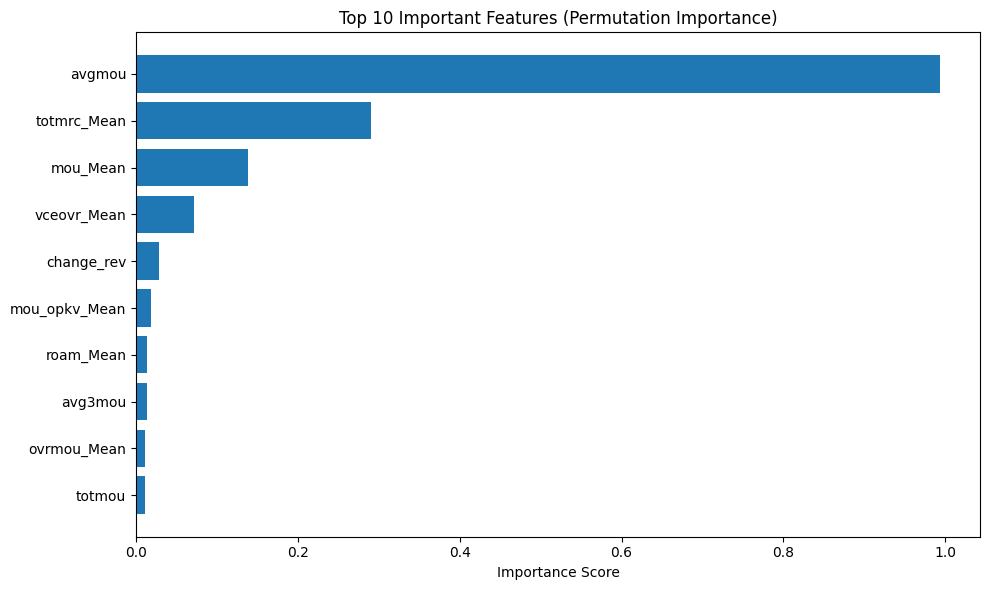

In [ ]:
# ၁။ Permutation Importance တွက်ချက်ခြင်း (n_jobs=1 သို့ ပြောင်းပါ)
result = permutation_importance(
    model_final,
    X_test_scaled_c,
    y_test_c,
    n_repeats=10,
    random_state=42,
    n_jobs=1  # <--- ဒီနေရာကို ပြင်ပါ
)

# ၂။ အရေးအကြီးဆုံး Feature 10 ခုကို ရွေးထုတ်ခြင်း
sorted_idx = result.importances_mean.argsort()[-10:]

# ၃။ ပုံဖော်ခြင်း
plt.figure(figsize=(10, 6))
plt.title('Top 10 Important Features (Permutation Importance)')
plt.barh(range(len(sorted_idx)), result.importances_mean[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [X_num_clean.columns[i] for i in sorted_idx])
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

##===Figure 2 -Revenue By Custommer Segment===

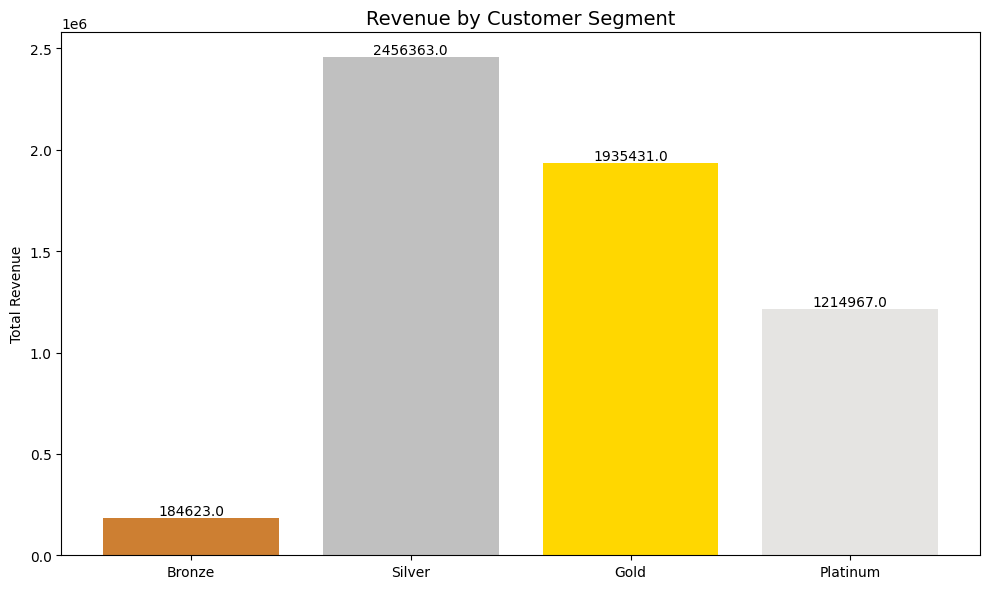

In [ ]:
# ၁။ ခန့်မှန်းချက်များကို ရယူပြီး df ထဲသို့ ထည့်သွင်းခြင်း
# သင်၏ model_final သည် clean လုပ်ထားသော data (X_num_clean) ကို train ထားခြင်းဖြစ်သည်
y_pred = model_final.predict(X_test_scaled_c)

# သတိပြုရန် - y_pred သည် test set အတွက်သာ ဖြစ်သောကြောင့်
# တစ်ခုလုံးအတွက် လိုချင်ပါက X_num_clean တစ်ခုလုံးကို predict လုပ်ရပါမည်
all_preds = model_final.predict(scaler.transform(X_num_clean))
df['predicted_avgrev'] = all_preds

# ၂။ Segment ခွဲခြင်း
df['revenue_segment'] = pd.cut(
    df['predicted_avgrev'],
    bins=[0, 30, 60, 100, float('inf')],
    labels=['Bronze', 'Silver', 'Gold', 'Platinum']
)

# ၃။ အုပ်စုအလိုက် တွက်ချက်ခြင်း
segment_summary = df.groupby('revenue_segment', observed=True).agg(
    customer_count=('revenue_segment', 'count'),
    avg_revenue=('avgrev', 'mean'),
    total_revenue=('avgrev', 'sum')
).reset_index()

# ၄။ Visualization
plt.figure(figsize=(10, 6))
bars = plt.bar(
    segment_summary['revenue_segment'],
    segment_summary['total_revenue'],
    color=['#cd7f32', '#c0c0c0', '#ffd700', '#e5e4e2']
)

plt.title('Revenue by Customer Segment', fontsize=14)
plt.ylabel('Total Revenue')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 0), va='bottom', ha='center')

plt.tight_layout()
plt.show()

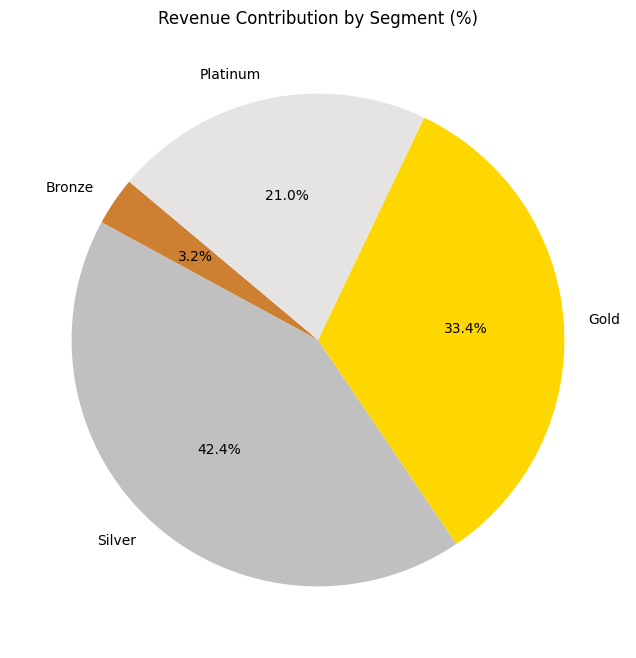

In [ ]:
# ၅။ Pie Chart ထပ်ပေါင်းခြင်း
plt.figure(figsize=(8, 8))
plt.pie(
    segment_summary['total_revenue'],
    labels=segment_summary['revenue_segment'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#cd7f32', '#c0c0c0', '#ffd700', '#e5e4e2']
)
plt.title('Revenue Contribution by Segment (%)')
plt.show()

##==== Figure 3: Actual vs Predicted ====

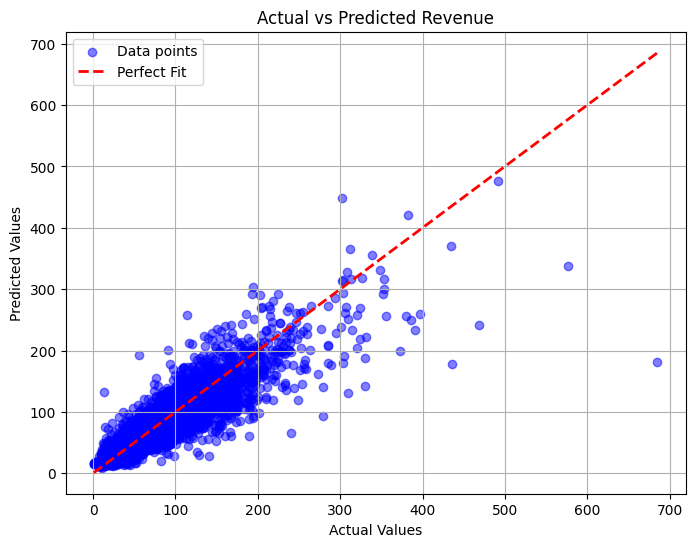

In [ ]:
# 5. Model Evaluation and Visualization

# Prediction for testing set
y_test_pred = model_final.predict(X_test_scaled_c)

# --- Plot 1: Actual vs Predicted (Standard Scatter Plot) ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test_c, y_test_pred, alpha=0.5, color='blue', label='Data points')
# Perfect prediction line (Red diagonal line)
plt.plot([y_test_c.min(), y_test_c.max()], [y_test_c.min(), y_test_c.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Revenue')
plt.legend()
plt.grid(True)
plt.show()



## ===Figure 5: Residual Distribution (Standard Histogram with KDE)===

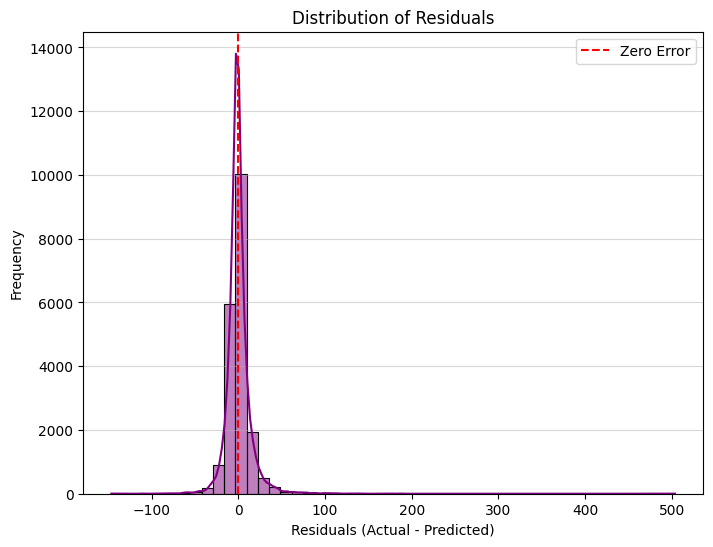

In [ ]:
# --- Plot 2: Residual Distribution (Standard Histogram with KDE) ---
residuals = y_test_c - y_test_pred

plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='purple', bins=50)
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

##**Section 4 :Model Application & Business Impact**

## Business Recommendations

1. Use the model to identify high-value customers (Platinum/Gold).
2. Apply targeted retention strategies for customers with declining revenue.
3. Allocate marketing budgets based on customer segments.



## Future Work

- Deploy the model as a real-time API for live predictions.
- Integrate with a dashboard for business monitoring.
- Test other models like XGBoost or Neural Networks for comparison.

## Limitations

- The model performs slightly worse on high-revenue (Platinum) customers.
- Demographic features (income, ethnicity) were not used in the model.
- Predictions are based on historical data; future behavior may change.

## Notebook Information

- Author: [Kyaw Zin Oo]
- Date: June 2026
- Purpose: GCI World 2026 Final Assignment – Business Proposal